[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Sample cleaned text:
 wondering anyone could enlighten car saw day 2door sports car looked late 60s early 70s called bricklin doors really small addition front bumper separate rest body know anyone tellme model name engine specs years production car made history whatever info funky looking car please email


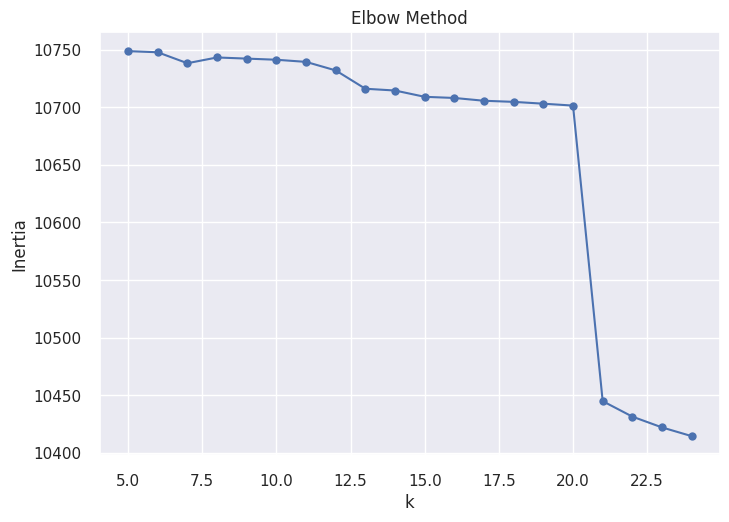

Cluster assignments: [2 2 2 2 4 4 2 2 2 2 2 4 4 4 2 4 4 4 4 2]

Cluster 0 top terms:
mileage, highway, covers, charles, affect, travel, comment, building, thinking, ive

Cluster 1 top terms:
repair, educational, mail, sales, tax, order, apple, cpu, computers, probably

Cluster 2 top terms:
thanks, please, anyone, windows, email, know, use, drive, would, card

Cluster 3 top terms:
devices, serial, mac, available, number, limits, ports, use, connect, increase

Cluster 4 top terms:
would, one, dont, people, think, like, get, know, good, well

Silhouette Score: -0.010167292765950237


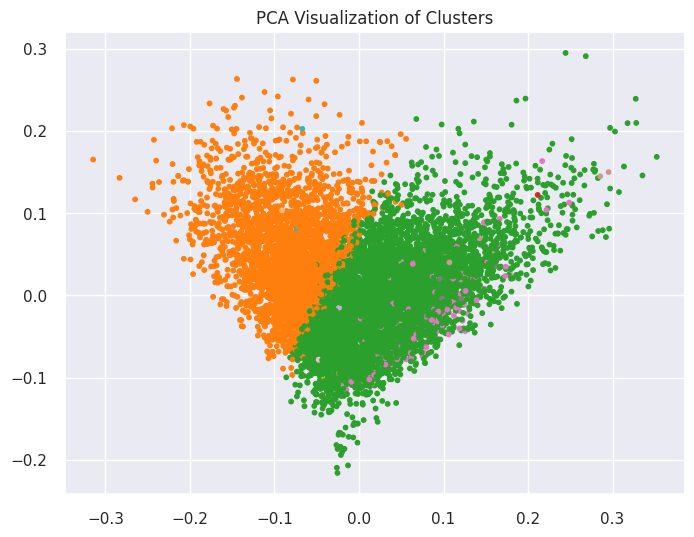

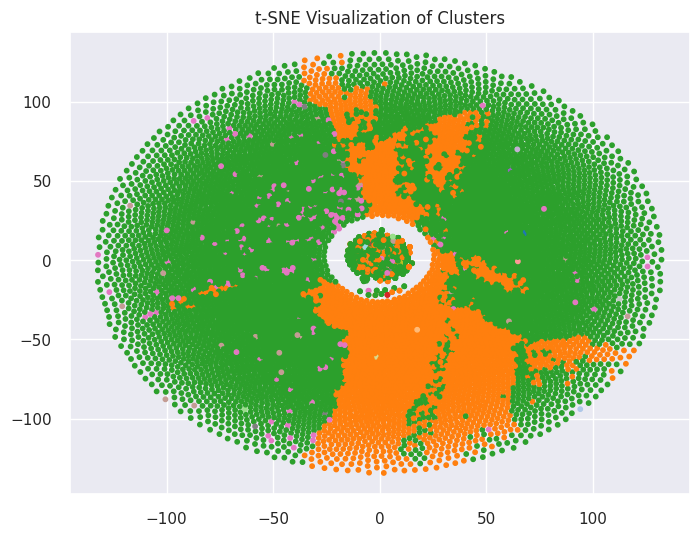


Document: The government passed a new healthcare bill
Predicted Cluster: 4

Document: The hockey team won the championship
Predicted Cluster: 4

Document: NASA announced a new space mission
Predicted Cluster: 4

Assignment complete — text preprocessing, clustering, visualization, and prediction finished.


In [1]:
# ============================================================
# 📌 TEXT CLUSTERING WITH 20 NEWSGROUPS — FULL PROJECT (ONE PAGE)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

nltk.download("stopwords")
stop_words = nltk.corpus.stopwords.words("english")

plt.style.use("seaborn-v0_8")
sns.set_theme()

# ============================================================
# 1. LOAD & PREPROCESS TEXT DATA
# ============================================================

data = fetch_20newsgroups(subset="train", remove=("headers", "footers", "quotes"))
texts = data.data

def preprocess(text):
    text = text.lower()
    text = "".join(ch for ch in text if ch not in string.punctuation)
    tokens = [t for t in text.split() if t not in stop_words]
    return " ".join(tokens)

clean_texts = [preprocess(t) for t in texts]

print("Sample cleaned text:\n", clean_texts[0][:300])

# ============================================================
# 2. TEXT REPRESENTATION (BoW, TF-IDF, Embeddings)
# ============================================================

# Bag of Words
bow_vec = CountVectorizer(max_features=5000)
X_bow = bow_vec.fit_transform(clean_texts)

# TF-IDF
tfidf_vec = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vec.fit_transform(clean_texts)

# Simple word embeddings (GloVe 50d)
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

embeddings = {}
with open("glove.6B.50d.txt", "r", encoding="utf8") as f:
    for line in f:
        vals = line.split()
        embeddings[vals[0]] = np.asarray(vals[1:], dtype="float32")

def doc_embed(doc):
    words = doc.split()
    vecs = [embeddings[w] for w in words if w in embeddings]
    return np.mean(vecs, axis=0) if vecs else np.zeros(50)

X_embed = np.array([doc_embed(t) for t in clean_texts])

# ============================================================
# 3. K-MEANS CLUSTERING (Using TF-IDF)
# ============================================================

# Elbow method
inertias = []
for k in range(5, 25):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_tfidf)
    inertias.append(km.inertia_)

plt.plot(range(5, 25), inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

# Choose k = 20 (matches dataset)
kmeans = KMeans(n_clusters=20, random_state=42)
clusters = kmeans.fit_predict(X_tfidf)

print("Cluster assignments:", clusters[:20])

# ============================================================
# 4. CLUSTER INTERPRETATION
# ============================================================

terms = tfidf_vec.get_feature_names_out()
order = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(5):
    print(f"\nCluster {i} top terms:")
    print(", ".join(terms[order[i, :10]]))

# ============================================================
# 5. MODEL EVALUATION (Silhouette Score)
# ============================================================

score = silhouette_score(X_tfidf, clusters)
print("\nSilhouette Score:", score)

# ============================================================
# 6. DIMENSIONALITY REDUCTION (PCA + t-SNE)
# ============================================================

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_tfidf.toarray())

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="tab20", s=10)
plt.title("PCA Visualization of Clusters")
plt.show()

# t-SNE
tsne = TSNE(n_components=2, perplexity=40, random_state=42)
X_tsne = tsne.fit_transform(X_tfidf.toarray())

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap="tab20", s=10)
plt.title("t-SNE Visualization of Clusters")
plt.show()

# ============================================================
# 7. PREDICT CLUSTERS FOR NEW DOCUMENTS
# ============================================================

new_docs = [
    "The government passed a new healthcare bill",
    "The hockey team won the championship",
    "NASA announced a new space mission"
]

new_clean = [preprocess(t) for t in new_docs]
new_tfidf = tfidf_vec.transform(new_clean)
predicted = kmeans.predict(new_tfidf)

for doc, c in zip(new_docs, predicted):
    print(f"\nDocument: {doc}\nPredicted Cluster: {c}")

print("\nAssignment complete — text preprocessing, clustering, visualization, and prediction finished.")